## Overfitting

Overfitting occurs when a machine learning model captures noise and patterns in the training data that do not generalize to unseen data. It results in a model that is too tailored to the training dataset, losing its ability to generalize.

**Analogy:**  for example, if you memorize exact answers for a test rather than understanding the underlying concepts, you may perform well on that test but struggle with any new questions.

### Why Does Overfitting Occur?

**Balance of Bias and Variance**

The bias-variance tradeoff is an important concept in understanding model performance:

- **Bias** refers to the error introduced by a model that is too simple. A model with high bias makes strong assumptions, leading to underfitting, where the model fails to capture the underlying patterns of the data.
- **Variance** is the error due to a model being too complex. High variance models are sensitive to the noise in training data, causing overfitting, where the model fits the training data very well but performs poorly on new, unseen data.

Overfitting occurs when a model has low bias and high variance, making it too sensitive to the specific data points in the training set, resulting in poor generalization to new data. The goal is to find a balance where both bias and variance are minimized for optimal model performance.

![image.png](attachment:image.png)

### Symptoms of Overfitting

- **Training vs. Testing Performance:** Overfitting can be identified by evaluating the model’s performance on both the training and testing datasets:
- **High Training Accuracy, Low Testing Accuracy:** Overfitting is indicated by a model that performs very well on training data but poorly on testing data.
- **Learning Curves:** Training curve shows high accuracy (or low loss), indicating the model fits the training data well. However, the validation curve diverges and plateaus, showing poor performance on unseen data.
![image-2.png](attachment:image-2.png)
- **High Variance in Predictions:** Models that overfit can have wildly different predictions when small changes are made to the input data.

### Example: Polynomial Regression Overfitting

Suppose we have some data points that follow a general quadratic trend but have some noise. We’ll use a high-degree polynomial (e.g., 15th-degree) to fit the data, which will result in overfitting.

We'll first demonstrate how linear regression will do if we don't handle the data's complexity and fit the model upright

In [ ]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
# Generate some noisy data
np.random.seed(42)
X = np.sort(2 * np.random.rand(100, 1) - 1, axis=0)  # Random X values in range [-1, 1]
y = X**2 - 0.5 * X + 0.2 + 0.1 * np.random.randn(100, 1)  # Quadratic trend with noise

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
#Test the model with just linear regression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

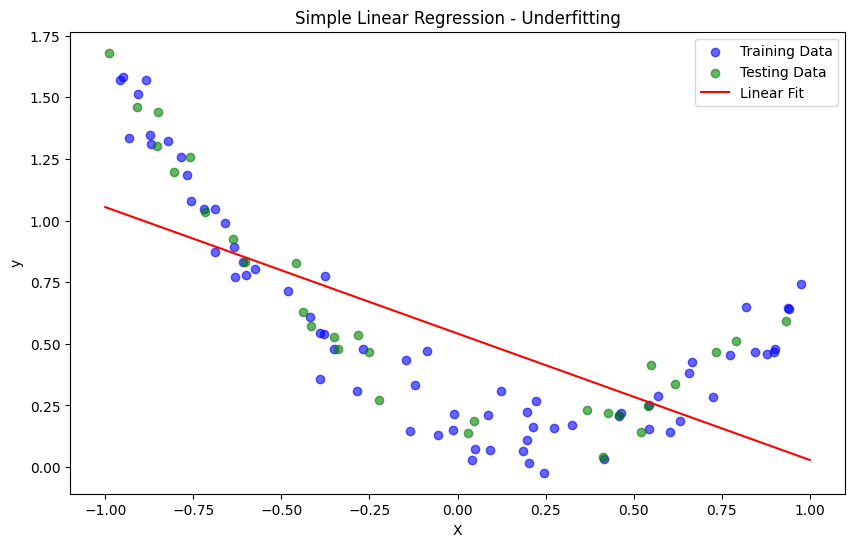

In [ ]:
# Visualization of the data and Linear regression fit
plt.figure(figsize=(10, 6))

# Plot training data
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)
# Plot testing data
plt.scatter(X_test, y_test, color='green', label='Testing Data', alpha=0.6)

# Plot the Linear regression fit
y_plot_linear = model.predict(X_plot)
plt.plot(X_plot, y_plot_linear, color='red', label='Linear Fit')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Simple Linear Regression - Underfitting')
plt.legend()
plt.show()

### Now let's use polynomial regression and try to handle the model's complexity

In [ ]:
from sklearn.metrics import r2_score

# Compute R^2 scores for training and test data
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Print R^2 scores
print(f"R^2 score on Training Data: {r2_train:.3f}")
print(f"R^2 score on Test Data: {r2_test:.3f}")

R^2 score on Training Data: 0.475
R^2 score on Test Data: 0.598


In [ ]:
# Fit a high-degree polynomial regression model
poly_features = PolynomialFeatures(degree=17)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

In [ ]:
#fit the model with polynomial features
model.fit(X_poly_train, y_train)

LinearRegression()

In [ ]:
# Make predictions
y_train_pred = model.predict(X_poly_train)
y_test_pred = model.predict(X_poly_test)

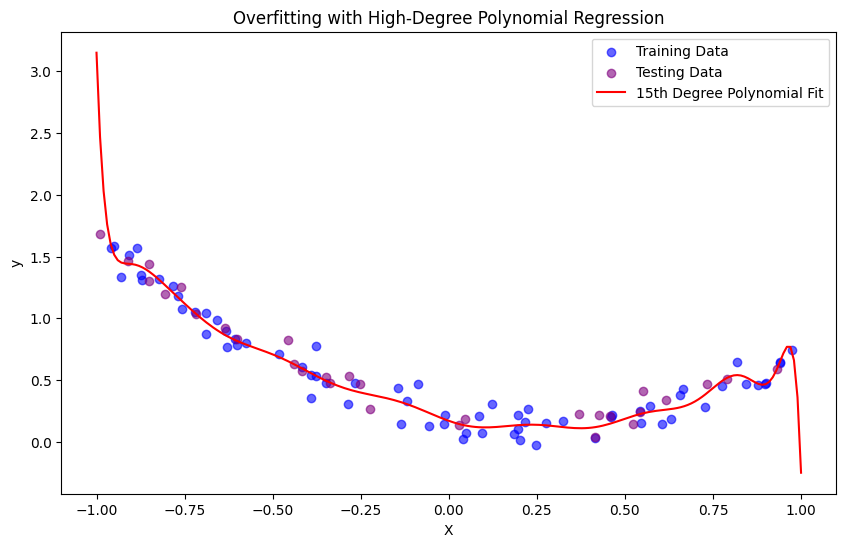

In [ ]:
# Plot the results
plt.figure(figsize=(10, 6))

# Plot training data
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)
# Plot testing data
plt.scatter(X_test, y_test, color='purple', label='Testing Data', alpha=0.6)

# Plot the high-degree polynomial fit
X_plot = np.linspace(-1, 1, 200).reshape(-1, 1)
y_plot = model.predict(poly_features.transform(X_plot))
plt.plot(X_plot, y_plot, color='red', label='15th Degree Polynomial Fit')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Overfitting with High-Degree Polynomial Regression')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

# Compute R^2 scores for training and test data
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Print R^2 scores
print(f"R^2 score on Training Data: {r2_train:.3f}")
print(f"R^2 score on Test Data: {r2_test:.3f}")

R^2 score on Training Data: 0.960
R^2 score on Test Data: 0.881


## Challenge

Tweak the degree of the polynomial and make the model generalize better. Compare the your model's r^2 with the previous model using visualization

In [ ]:
# Fit a high-degree polynomial regression model
poly_features = PolynomialFeatures(degree=5)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

In [ ]:
#fit the model with polynomial features
model.fit(X_poly_train, y_train)

LinearRegression()

In [ ]:
# Make predictions
y_train_pred = model.predict(X_poly_train)
y_test_pred = model.predict(X_poly_test)

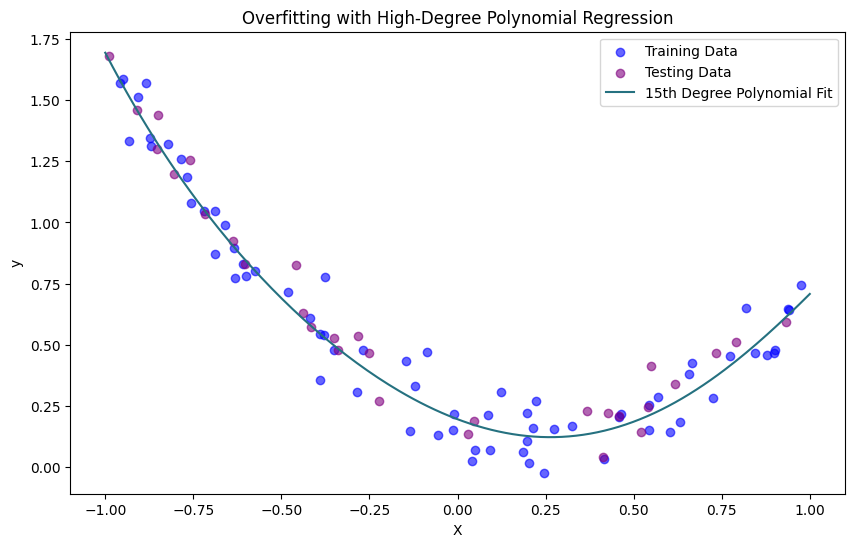

In [ ]:
# Plot the results
plt.figure(figsize=(10, 6))

# Plot training data
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)
# Plot testing data
plt.scatter(X_test, y_test, color='purple', label='Testing Data', alpha=0.6)

# Plot the high-degree polynomial fit
X_plot = np.linspace(-1, 1, 200).reshape(-1, 1)
y_plot = model.predict(poly_features.transform(X_plot))
plt.plot(X_plot, y_plot, color='#257180', label='15th Degree Polynomial Fit')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Overfitting with High-Degree Polynomial Regression')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

# Compute R^2 scores for training and test data
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Print R^2 scores
print(f"R^2 score on Training Data: {r2_train:.3f}")
print(f"R^2 score on Test Data: {r2_test:.3f}")

R^2 score on Training Data: 0.954
R^2 score on Test Data: 0.968


## How to address overfitting

### Regularization
Regularization is a technique used in machine learning to prevent overfitting by adding a penalty term to the model’s objective function. This penalty discourages the model from being too complex and helps it generalize better to unseen data. By controlling model complexity, regularization aims to find a balance between underfitting and overfitting.

### Types of regularization
**L1 Regularization (Lasso)**
- L1 regularization adds a penalty term equal to the sum of the absolute values of the model’s coefficients. This penalty forces some coefficients to become exactly zero, effectively performing feature selection.
- Encourages sparsity by reducing the importance of irrelevant features. The model becomes simpler and is less likely to overfit.
-  L1 regularization is useful when you expect many features to be irrelevant or when you want to perform feature selection automatically.

**L2 Regularization (Ridge)**
- L2 regularization adds a penalty term equal to the sum of the squared values of the model’s coefficients. Unlike L1, it does not set any coefficients exactly to zero but instead shrinks them closer to zero.
- It reduces the size of the coefficients, making the model less sensitive to noise in the data and thus reducing overfitting.
-  L2 regularization is useful when you want to reduce model complexity while keeping all features. It is commonly used when all features are thought to be relevant, but some should have less influence.

**Elastic Net Regularization **
- Elastic Net combines both L1 and L2 regularization penalties, capturing the benefits of both. It adds both absolute and squared coefficient penalties to the model’s objective function.
- Elastic Net can handle situations where there are multiple correlated features. It combines the sparsity of L1 regularization with the coefficient shrinkage of L2, providing a more balanced approach.
- Use Elastic Net when you expect some features to be irrelevant (like L1) but also have multicollinearity among features (like L2).

### Choosing a Regularization technique
- If you suspect many features are irrelevant: Use **L1 Regularization (Lasso).**
- If you believe all features are important but need to reduce their impact: Use **L2 Regularization (Ridge).**
- If you want a balance of both sparsity and coefficient shrinkage: Use **Elastic Net.**

### Implementation

Now, let's use the overfitted model and apply regularization techniques to see whether it handles overfitting well. First, we'll set up the model like the one we set up first.

R^2 score on Training Data: 0.955
R^2 score on Test Data: 0.969


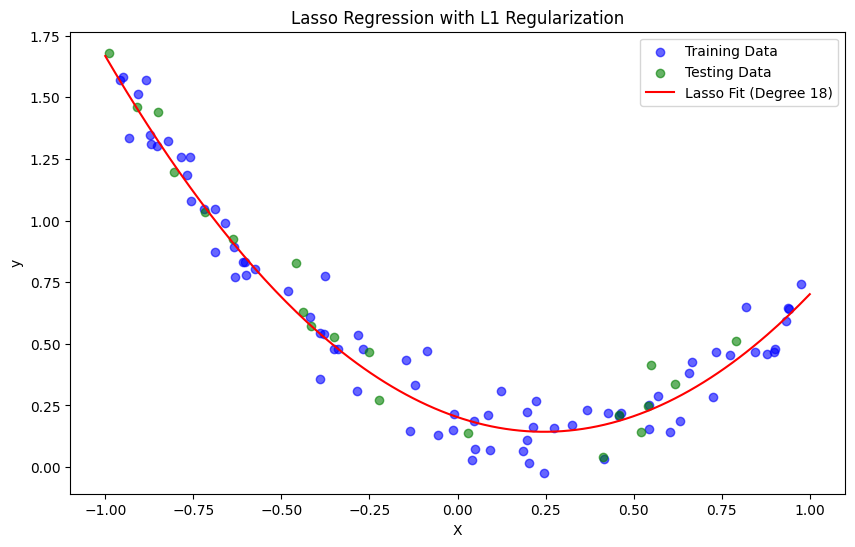

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Generate some noisy data
np.random.seed(42)
X = np.sort(2 * np.random.rand(100, 1) - 1, axis=0)  # Random X values in range [-1, 1]
y = X**2 - 0.5 * X + 0.2 + 0.1 * np.random.randn(100, 1)  # Quadratic trend with noise

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the degree of the polynomial for transformation
degree = 18

# Transform the features into polynomial features
poly_features = PolynomialFeatures(degree=degree)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

# Lasso regression model with L1 regularization
alpha = 0.001  # Regularization strength (tune this parameter)
lasso_model = Lasso(alpha=alpha, max_iter=10000)
lasso_model.fit(X_poly_train, y_train)

# Make predictions
y_train_pred = lasso_model.predict(X_poly_train)
y_test_pred = lasso_model.predict(X_poly_test)

# Compute R^2 scores for training and test data
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Print R^2 scores
print(f"R^2 score on Training Data: {r2_train:.3f}")
print(f"R^2 score on Test Data: {r2_test:.3f}")

# Visualization of the data and Lasso regression fit
plt.figure(figsize=(10, 6))

# Plot training data
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)
# Plot testing data
plt.scatter(X_test, y_test, color='green', label='Testing Data', alpha=0.6)

# Plot the Lasso regression fit
X_plot = np.linspace(-1, 1, 200).reshape(-1, 1)
y_plot = lasso_model.predict(poly_features.transform(X_plot))
plt.plot(X_plot, y_plot, color='red', label=f'Lasso Fit (Degree {degree})')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Lasso Regression with L1 Regularization')
plt.legend()
plt.show()

## Challenge:
Try to fit an L2 regularization and elastic net using the same dataset above.

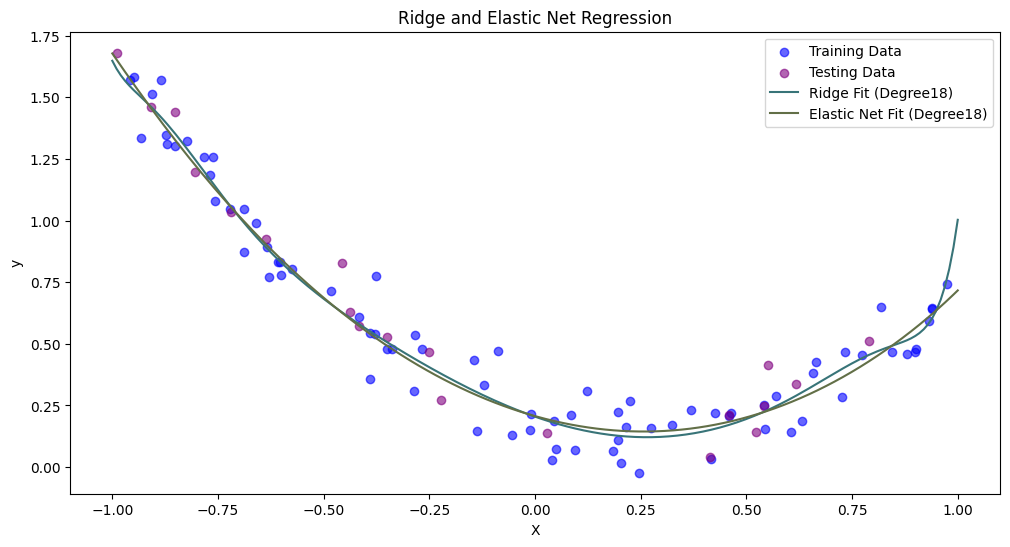

R^2 score on Training Data (Ridge):0.957
R^2 score on Test Data (Ridge):0.971
R^2 score on Training Data (Elastic Net):0.955
R^2 score on Test Data (Elastic Net):0.968


In [ ]:
# RIDGE REGRESSION (L2 Regularization)
from sklearn.linear_model import Ridge, ElasticNet
ridge = Ridge(alpha=alpha).fit(X_poly_train, y_train)

# Make predictions
y_train_pred_ridge = ridge.predict(X_poly_train)
y_test_pred_ridge = ridge.predict(X_poly_test)

# Compute R^2 scores
r2_train_ridge = r2_score (y_train,y_train_pred_ridge)
r2_test_ridge = r2_score(y_test,y_test_pred_ridge)

# ELASTIC NET
alpha = 0.001 # Combined regularization strength (tune this para meter)
l1_ratio = 0.5 # Ratio of L1 to L2 penalty (tune this parameter)
elastic_net_model = ElasticNet(alpha=alpha,l1_ratio=l1_ratio)
elastic_net_model.fit(X_poly_train,y_train)

# Make predictions
y_train_pred_en = elastic_net_model.predict(X_poly_train)
y_test_pred_en = elastic_net_model.predict(X_poly_test)

# Compute R^2 scores
r2_train_en = r2_score (y_train,y_train_pred_en)
r2_test_en = r2_score(y_test,y_test_pred_en)

# Visualization
plt.figure(figsize=(12, 6))

# Plot training data
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)
# Plot testing data
plt.scatter(X_test, y_test, color='purple', label='Testing Data', alpha=0.6)

# Plot the Ridge Regression fit
y_plot_ridge = ridge.predict(poly_features.transform(X_plot))
plt.plot(X_plot,y_plot_ridge,color='#387478',label=f'Ridge Fit (Degree{degree})')

# Plot the Elatic Net fit
y_plot_elastic = elastic_net_model.predict(poly_features.transform(X_plot))
plt.plot(X_plot,y_plot_elastic,color='#626F47',label=f'Elastic Net Fit (Degree{degree})')


plt.xlabel('X')
plt.ylabel('y')
plt.title('Ridge and Elastic Net Regression')
plt.legend()
plt.show()

#print R^2 scores
print(f"R^2 score on Training Data (Ridge):{r2_train_ridge:.3f}")
print(f"R^2 score on Test Data (Ridge):{r2_test_ridge:.3f}")
print(f"R^2 score on Training Data (Elastic Net):{r2_train_en:.3f}")
print(f"R^2 score on Test Data (Elastic Net):{r2_test_en:.3f}")